In [1]:
import pandas as pd
import os
from tqdm import tqdm
import re
import json
import numpy as np
import random
import shutil
from multiprocessing import Pool
import nltk

tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.chunk import ne_chunk
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import string
from concurrent.futures import ProcessPoolExecutor



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/effixis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/effixis/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /home/effixis/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /home/effixis/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv("data/intermediary/risk_factors.csv")

# 3. Count words occurences

In [3]:
df

,_year_cik,_year,_cik,_content
0,2006_1000045,2006,1000045,"The following factors, as well as other factor..."
1,2006_1000180,2006,1000180,Our operating results may fluctuate significan...
2,2006_1000209,2006,1000209,Interest rate fluctuations may adversely affec...
3,2006_1000227,2006,1000227,Investing in our securities involves risks. Yo...
4,2006_1000228,2006,1000228,The healthcare products distribution industry ...
...,...,...,...,...
114698,2022_98362,2022,98362,The following are certain risk factors that co...
114699,2022_99250,2022,99250,"FORWARD-LOOKING STATEMENTS \n The reports, fil..."
114700,2022_99302,2022,99302,You should carefully consider the following\nr...
114701,2022_99780,2022,99780,. \n Our business is subject to a number of ri...


In [4]:
cyber_keywords = [x.split(", ") for x in """access control, authorization, permission, entry control
attacker, hacker, intruder, assailant, adversary
authentication, verification, identity check
breach in security, security breach, compromise
cloud safety, cloud protection, cloud integrity
cloud security, cloud protection, cloud defense
computer attacks, computer assault, system attacks
computer breach, system breach, computer intrusion
computer intrusion, unauthorized access, system intrusion
computer malware, malicious software, computer virus
computer security, system security, IT security
computer virus, malware, worm, trojan
cyber attack, online attack, digital assault
cyber incident, cyber event, security incident
cyber intrusions, cyber breaches, cyber penetrations
cyber risk, digital risk, online risk
cyber security, IT security, online security
cyber threat, digital threat, online threat
cyber threats, online dangers, digital threats
cyberattack, online attack, web attack
cyberattacks, online offenses, web assaults
cybersecurity, information security, net security
data breach, data compromise, data leak
data integrity, data consistency, data accuracy
data leakage, data spill, data exposure
data loss, data disappearance, data deletion
data security, data protection, information security
data stealing, data theft, data pilfering
data theft, unauthorized data access, data steal
datacenter attack, datacenter breach, server attack
denial of service, DoS, service disruption,
denial-of-service, DoS, service outage
digital breach, online breach, web breach
digital leak, online leak, web leak
digital loss, online loss, web loss
digital security, online security, web security
encrypt, cipher, code, scramble
encryption, coding, ciphering, cryptograph
exfiltration, data extraction, data leakage
exposed data, leaked data, unprotected data
firewall, barrier, security wall
hacker, cracker, cybercriminal
hacking, cyberattack, breaching
information leak, data breach, data leakage
information risk, data risk, cyber risk
information security, infosec, data protection
information system, IT system, tech system
information system attacks, system breaches, system intrusions
infosec, cybersecurity, IT security
infrastructure attack, facility breach, structure attack
inside threat, internal threat, inside risk
insider threat, employee threat, trusted threat
intrusion, breach, unauthorized access
it asset, tech resource, IT property
malicious, harmful, malevolent
malware, virus, trojan
network attack, connectivity breach, network breach
network integrity, network consistency, network health
network resilience, network robustness, network recovery
network security, network protection, network defense
network threats, network risks, connectivity threats
phishing, email scam, spear phishing
programs breach, software breach, app intrusion
security breach, security violation, unauthorized access
security expenditure, security costs, security spending
security incident, security event, security issue
security integrity, security consistency, security trust
security measure, security step, protection method
security monitoring, security oversight, intrusion detection
security policy, security guidelines, security procedures
security program, security plan, protection program
services threat, service risks, service vulnerabilities
social engineering, human hacking, psychological manipulation
software assurance, software guarantee, software reliability
software breach, software intrusion, app breach
spoof, impersonation, mimic
spyware, adware, surveillance software
system attack, infrastructure breach, system breach
system integrity, system consistency, system trust
system security, infrastructure security, system protection
system threat, system risk, infrastructure risk
systems attack, multiple system breaches, platform attacks
systems threat, multiple system risks, platform threats
third party breach,external breach,vendor breach,supplier compromise
unauthorized access,illegal access,illicit entry,unauthorized entry
antispyware,anti-spyware,spyware protection
antivirus,anti-virus,malware protection
blocklist,blacklist,denylist
confidentiality,secrecy,privacy
cookie,web cookie,browser cookie
decipher,decode,unscramble
decode,decipher,uncode
decrypt,unencrypt,decode
decryption,decoding,cipher breaking
encode,encrypt,code
hash,checksum
hashing,encryption,encoding
password,passphrase,secret key
protocol,standard,procedure
proxy,intermediary,proxy server
public-key,asymmetric key
ransomware,crypto-ransomware,encrypting malware
spam,junk mail,unsolicited mail
information theft,data theft,info breach
trojan,trojan horse,malicious software
two-factor,2FA,dual authentication
vulnerability assessment,vulnerability evaluation,vulnerability appraisal
vulnerability management,vulnerability handling,vulnerability oversight
vulnerability scanning,vulnerability scan,vulnerability search
vulnerability exploit,vulnerability abuse,vulnerability use
vulnerability patching,vulnerability fix,vulnerability repair
vulnerability analysis,vulnerability examination,vulnerability review
software vulnerability,program vulnerability,application weakness
network vulnerability,system vulnerability,infrastructure weakness
system vulnerability,platform vulnerability,hardware vulnerability
security vulnerability,protection vulnerability
vulnerability disclosure,vulnerability announcement,vulnerability report
zero-day vulnerability,0-day vulnerability,undisclosed vulnerability
remote code execution vulnerability,RCE vulnerability,remote exploit
database vulnerability,DB vulnerability,data store weakness
application vulnerability,app vulnerability,software flaw
penetration testing,pentesting,ethical hacking
security auditing,security examination,security review
intrusion detection system,intrusion detection
intrusion prevention system,intrusion blocking
secure sockets layer,SSL,secure socket
transport layer security,TLS,transport security
virtual private network,VPN,private network
firewall configuration, firewall setup, firewall rules, firewall settings
multi-factor authentication, 2FA, MFA, two-factor authentication
brute force attack, password guessing, brute force method
security architecture, security framework, security structure
endpoint protection, endpoint security, device protection
security operations center, security hub
security information and event management, SIEM, security event management
risk assessment, threat assessment, vulnerability analysis
data encryption standard, data protection standard
advanced encryption standard, advanced data encryption
public key infrastructure, PKI, digital certificate infrastructure
domain name system security, DNSSEC, DNS security
secure/multipurpose internet mail extensions, S/MIME, encrypted email
botnet, zombie network, robot network
social engineering attack, human hacking, manipulation attack
spear phishing, targeted phishing, spear-phish
zero trust architecture, zero trust model, zero trust framework
security compliance, security standards, security regulations
secure coding, security programming, secure code practices
sandboxing, isolation, secure environment
threat intelligence, threat analysis, threat insights
incident response plan, IRP, security response strategy
chain of custody, evidence trail, evidence handling
data masking, data obfuscation, data hiding
digital forensics, electronic forensics, e-forensics
man-in-the-middle attack, MITM, session hijacking
dark web monitoring, hidden web tracking, deep web monitoring
certificate authority, certification entity
secure file transfer protocol (sftp), encrypted FTP, secure FTP
endpoint detection and response (edr), device threat detection, endpoint monitoring
web application firewall (waf), application firewall, WAF system
privilege escalation, privilege increase, elevated permissions""".lower().split("\n")]

In [5]:
def count_kw_cyber(kws):
    return df['_content'].apply(lambda x: 0 if isinstance(x, float) else sum([x.lower().count(kw.lower()) for kw in kws]))

In [6]:
results = []

for kws in tqdm(cyber_keywords):
    results.append(count_kw_cyber(kws))

100%|██████████| 160/160 [27:01<00:00, 10.14s/it]


In [7]:
indices = [kws[0] for kws in cyber_keywords]

In [8]:
for result, kw in tqdm(zip(results, indices)):
    df[kw] = result

77it [00:00, 769.69it/s]/tmp/ipykernel_10397/898473829.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[kw] = result
/tmp/ipykernel_10397/898473829.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[kw] = result
/tmp/ipykernel_10397/898473829.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()

In [9]:
df

,_year_cik,_year,_cik,_content,access control,attacker,authentication,breach in security,cloud safety,cloud security,...,chain of custody,data masking,digital forensics,man-in-the-middle attack,dark web monitoring,certificate authority,secure file transfer protocol (sftp),endpoint detection and response (edr),web application firewall (waf),privilege escalation
0,2006_1000045,2006,1000045,"The following factors, as well as other factor...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006_1000180,2006,1000180,Our operating results may fluctuate significan...,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2006_1000209,2006,1000209,Interest rate fluctuations may adversely affec...,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,2006_1000227,2006,1000227,Investing in our securities involves risks. Yo...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006_1000228,2006,1000228,The healthcare products distribution industry ...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114698,2022_98362,2022,98362,The following are certain risk factors that co...,1,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,0
114699,2022_99250,2022,99250,"FORWARD-LOOKING STATEMENTS \n The reports, fil...",0,1,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
114700,2022_99302,2022,99302,You should carefully consider the following\nr...,1,1,0,7,0,0,...,0,0,0,1,0,0,0,0,0,0
114701,2022_99780,2022,99780,. \n Our business is subject to a number of ri...,0,0,0,1,0,0,...,0,0,0,4,0,0,0,0,0,0


In [10]:
df['occurences'] = df[indices].apply(list, axis = 1)
df.drop(columns = indices, inplace = True)
df.drop(columns = ['_content'], inplace = True)

In [11]:
df

,_year_cik,_year,_cik,occurences
0,2006_1000045,2006,1000045,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2006_1000180,2006,1000180,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2006_1000209,2006,1000209,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,2006_1000227,2006,1000227,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,2006_1000228,2006,1000228,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
114698,2022_98362,2022,98362,"[1, 1, 0, 3, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
114699,2022_99250,2022,99250,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, ..."
114700,2022_99302,2022,99302,"[1, 1, 0, 7, 0, 0, 0, 0, 1, 1, 0, 1, 0, 3, 0, ..."
114701,2022_99780,2022,99780,"[0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [13]:
df.to_csv("data/intermediary/occurences_cyber_kws.csv", index = False)

# 3. Compute cyberrisk scores


## 3.1 Computations


In [ ]:
df_breaches = pd.read_excel("data/aa_plus_prc_breach_list_cik.xlsx")
df_breaches = df_breaches[~(df_breaches['year_breach'] == 2023)]
df_breaches['id'] = df_breaches.apply(lambda x: "_".join([str(x['year_breach']), str(x['cik'])]), axis = 1)
breaches_ciks = df_breaches['cik'].unique().tolist()
df['breach'] = df['_year_cik'].apply(lambda x: x in df_breaches['id'].values)
# Consider only the rows corresponding to (year, cik) pairs that have a breach
df_comparison = df[df['breach'] == True][['_year_cik', '_year', '_cik','occurences']]

In [ ]:
df_comparison

,_year_cik,_year,_cik,occurences
2665,2006_12978,2006,12978,"[0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4995,2006_715779,2006,715779,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5162,2006_732717,2006,732717,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6644,2006_900075,2006,900075,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7129,2006_935703,2006,935703,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
114249,2022_859070,2022,859070,"[0, 0, 1, 9, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0, ..."
114364,2022_884887,2022,884887,"[0, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, ..."
114588,2022_926326,2022,926326,"[0, 0, 0, 3, 0, 0, 0, 0, 1, 1, 0, 2, 0, 3, 0, ..."
114650,2022_943452,2022,943452,"[0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 2, 0, ..."


In [35]:
def cos_sim(A, B):
    """
    Compute the cosine similarity between two vectors A and B.
    
    Args:
    - A (numpy array): First vector.
    - B (numpy array): Second vector.
    
    Returns:
    - float: cosine similarity between A and B.
    """
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    if norm_B == 0.0:
        return 0
    return dot_product / (norm_A * norm_B)

In [36]:
df_comparison['_year'] = df_comparison['_year'].astype(int)
df['_year'] = df['_year'].astype(int)

In [37]:
df['similarities'] = df.apply(lambda x: 
    np.mean([
        cos_sim(x['occurences'], y)
        for y in df_comparison[df_comparison['_year'] == x['_year']-1]['occurences'].values
    ]),
    axis=1
)

/home/effixis/anaconda3/envs/mlenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/effixis/anaconda3/envs/mlenv/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_4692/2177454509.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (norm_A * norm_B)


In [38]:
df.rename(columns = {'similarities':'crscore'}, inplace = True)

In [39]:
df[['_year_cik','_year','_cik','crscore']].to_csv("data/results/crscores_cyber_kws.csv")

## 3.2 Correlations with Florackis et al

In [40]:
# Load dataframes
df = pd.read_csv('data/crscores_cyber_kws.csv', index_col = 0)
excel_df = pd.read_excel('data/florackis_etal_cs_score_cik.xlsx')
excel_df['cik'] = excel_df['cik'].astype(str)
df['_cik'] = df['_cik'].astype(str)

In [41]:
df.dropna(subset=['crscore'], inplace=True)

In [42]:
excel_df['_year_cik'] = excel_df.apply(lambda x: "_".join([str(x['fyear']), str(x['cik'])]), axis = 1)

In [47]:
df.merge(excel_df, left_on=['_year_cik'], right_on=['_year_cik'], how='inner').to_csv("data/results/correlations_cyber_kws.csv")

In [43]:
df_merged = df.merge(excel_df, left_on=['_year_cik'], right_on=['_year_cik'], how='inner')[['crscore_x', 'crscore_y']]

In [44]:
correlation = df_merged['crscore_x'].corr(df_merged['crscore_y'])

print(correlation)

0.6426489842221533


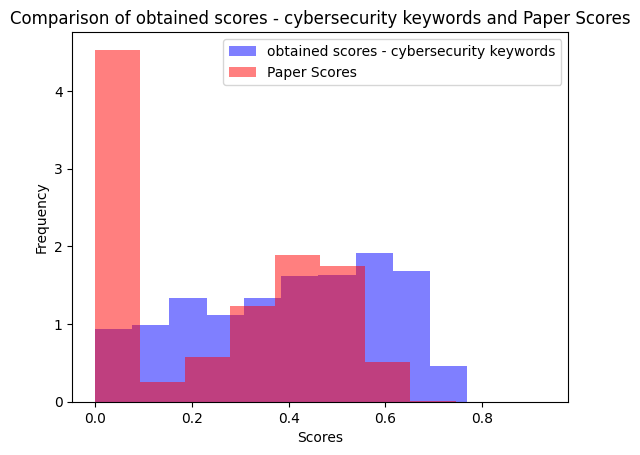

In [45]:
import matplotlib.pyplot as plt

my_scores = df['crscore'].fillna(0)
paper_scores = excel_df['crscore']

# Create histograms
plt.hist(my_scores, bins=10, alpha=0.5, label='obtained scores - cybersecurity keywords', color='blue', density=True)
plt.hist(paper_scores, bins=10, alpha=0.5, label='Paper Scores', color='red', density=True)

# Add legend
plt.legend(loc='upper right')

# Add labels and title
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.title('Comparison of obtained scores - cybersecurity keywords and Paper Scores')

# Display the plot
plt.show()
